<a href="https://colab.research.google.com/github/Binghui5728/SDG6-AI-midterm/blob/main/SDG6_Midterm_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### 專案目標：SDG 6 飲用水安全預測
與 Gemini 協作紀錄：詢問如何處理 Kaggle 水質數據的缺失值。

--- 原始數據摘要 ---
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

--- 各欄位缺失值統計 ---
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivit

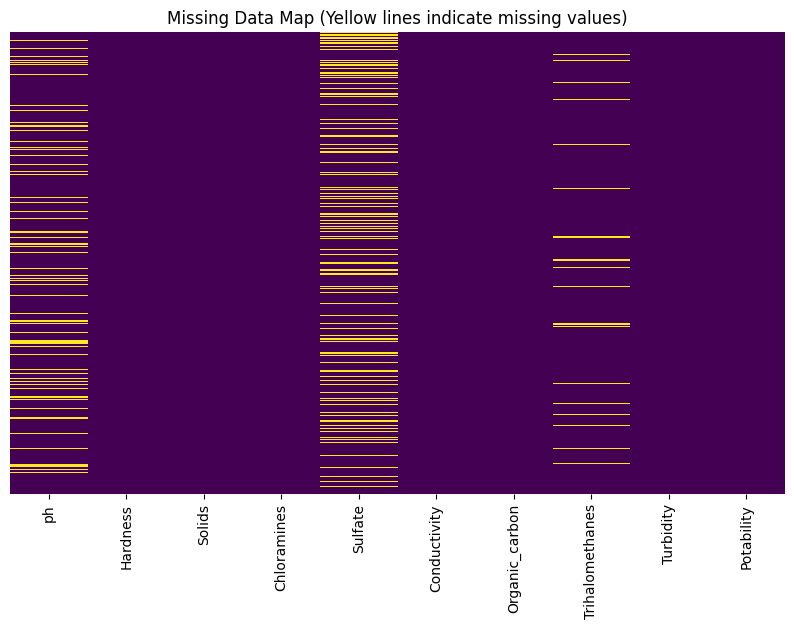

In [ ]:
import pandas as pd

# 1. 讀取從 Kaggle 下載的水質資料
# df = pd.read_csv('water_potability.csv') # 檔案已成功載入，此行暫時註解

# 2. 查看資料前五行（確認讀取成功）
print("--- 原始數據摘要 ---")
print(df.head())

# 3. 檢查缺失值（這部分可以詢問 Gemini 如何優化）
print("\n--- 各欄位缺失值統計 ---")
print(df.isnull().sum())

# 4. 簡單的數據探索視覺化
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Map (Yellow lines indicate missing values)")
plt.show()

### 處理缺失值與數據標準化

由於我們發現 `ph`, `Sulfate`, `Trihalomethanes` 欄位存在缺失值，我們將依序執行以下步驟：

1.  **缺失值填充**：使用各欄位的**中位數**來填充缺失值，因為中位數對異常值不如平均值敏感。
2.  **特徵標準化 (Standard Scaling)**：使用 StandardScaler 對所有數值特徵進行標準化。Standard Scaling 會將數據轉換為平均值為0，標準差為1的分布，這有助於許多機器學習模型獲得更好的性能，尤其是那些基於距離的模型。

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 使用中位數填充缺失值
# 找出有缺失值的數值欄位
missing_cols = ['ph', 'Sulfate', 'Trihalomethanes']

print("--- 填充前各欄位缺失值統計 ---")
print(df[missing_cols].isnull().sum())

for col in missing_cols:
    median_val = df[col].median()
    # 修正 FutureWarning: 避免使用 inplace=True，直接賦值給原始欄位
    df[col] = df[col].fillna(median_val)
    print(f"欄位 '{col}' 已使用中位數 {median_val:.2f} 進行填充")

print("\n--- 填充後各欄位缺失值統計 ---")
print(df[missing_cols].isnull().sum())

# 驗證所有缺失值是否都已填充
print("\n--- 檢查所有欄位是否還有缺失值 ---")
print(df.isnull().sum().sum())

# 顯示填充後的數據前五行
print("\n--- 填充缺失值後的數據前五行 ---")
print(df.head())

--- 填充前各欄位缺失值統計 ---
ph                 0
Sulfate            0
Trihalomethanes    0
dtype: int64
欄位 'ph' 已使用中位數 7.04 進行填充
欄位 'Sulfate' 已使用中位數 333.07 進行填充
欄位 'Trihalomethanes' 已使用中位數 66.62 進行填充

--- 填充後各欄位缺失值統計 ---
ph                 0
Sulfate            0
Trihalomethanes    0
dtype: int64

--- 檢查所有欄位是否還有缺失值 ---
0

--- 填充缺失值後的數據前五行 ---
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.036752  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246  333.073546    592.885359   
2  8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2  

In [ ]:
# 2. 進行 Standard Scaling

# 分離特徵 (X) 和目標變數 (y)
# 除了 'Potability' 之外的所有欄位都是特徵
X = df.drop('Potability', axis=1)
y = df['Potability']

# 初始化 StandardScaler
scaler = StandardScaler()

# 對特徵數據進行標準化
X_scaled = scaler.fit_transform(X)

# 將標準化後的數據轉換回 DataFrame，並保留欄位名稱
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("--- Standard Scaling 後的特徵數據前五行 ---")
print(X_scaled_df.head())

# 顯示 Standard Scaling 後的數據統計摘要
print("\n--- Standard Scaling 後的特徵數據描述 ---")
print(X_scaled_df.describe())

--- Standard Scaling 後的特徵數據前五行 ---
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0 -0.025474  0.259195 -0.139471     0.112415  0.965957      1.708954   
1 -2.284717 -2.036414 -0.385987    -0.307694 -0.014799      2.062575   
2  0.697319  0.847665 -0.240047     1.360594 -0.014799     -0.094032   
3  0.845393  0.547651  0.000493     0.592008  0.644130     -0.778830   
4  1.372982 -0.464429 -0.460249    -0.363698 -0.649522     -0.343939   

   Organic_carbon  Trihalomethanes  Turbidity  
0       -1.180651         1.305434  -1.286298  
1        0.270597        -0.639186   0.684218  
2        0.781117         0.000800  -1.167365  
3        1.255134         2.152154   0.848412  
4       -0.824357        -2.182297   0.138786  

--- Standard Scaling 後的特徵數據描述 ---
                 ph      Hardness        Solids   Chloramines       Sulfate  \
count  3.276000e+03  3.276000e+03  3.276000e+03  3.276000e+03  3.276000e+03   
mean   4.218576e-16  1.024821e-15 -4.012528e-17  5.

### 數據劃分：訓練集和測試集

在將數據用於模型訓練之前，我們需要將數據集劃分為訓練集和測試集。這樣做的目的是為了：

1.  **訓練模型**：使用訓練集來讓模型學習數據中的模式。
2.  **評估模型**：使用測試集來評估模型在未見過數據上的表現，判斷其泛化能力，避免過度擬合。

我們將使用 `sklearn.model_selection` 中的 `train_test_split` 函數，通常會將 80% 的數據用於訓練，20% 用於測試。


In [9]:
from sklearn.model_selection import train_test_split

# 將數據劃分為訓練集和測試集
# test_size=0.2 表示 20% 的數據用於測試，random_state 確保每次劃分結果一致
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"訓練集特徵形狀: {X_train.shape}")
print(f"測試集特徵形狀: {X_test.shape}")
print(f"訓練集目標形狀: {y_train.shape}")
print(f"測試集目標形狀: {y_test.shape}")

訓練集特徵形狀: (2620, 9)
測試集特徵形狀: (656, 9)
訓練集目標形狀: (2620,)
測試集目標形狀: (656,)


數據劃分完成後，您就可以開始選擇合適的機器學習模型進行訓練和評估了。例如，您可以嘗試邏輯回歸、支持向量機或決策樹等分類模型。

### 模型選擇與討論 (Model Selection and Discussion)

考量到我們的目標變數 `Potability` 是二元類別（0 或 1），這是一個典型的**二元分類問題**。因此，我們選擇 **Random Forest Classifier (隨機森林分類器)** 作為我們的預測模型。

**選用 Random Forest Classifier 的理由：**

1.  **非線性捕捉能力**：水質數據中各特徵（如 pH 值、硬度、氯胺等）與水是否可飲用之間的關係可能不是簡單的線性關係。隨機森林由多個決策樹組成，其樹狀結構能夠有效地捕捉複雜的非線性關係和特徵之間的交互作用。
2.  **抗噪能力與避免過擬合**：真實世界的水質數據可能包含異常值或測量誤差（噪聲）。隨機森林透過集成學習（Ensemble Learning）的方式，結合多個決策樹的預測結果，能夠顯著降低單一決策樹容易過度擬合的風險，提升模型的泛化能力。
3.  **特徵重要性輸出**：隨機森林能夠提供「特徵重要性」的評估，這有助於我們理解哪些水質參數對判斷水是否可飲用具有最大的影響力。這對於後續的環境分析或政策制定具有實際意義。
4.  **處理多變數類型**：Random Forest 可以直接處理數值型特徵，無需額外進行 One-Hot Encoding 等處理（如果存在類別特徵）。


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 初始化 Random Forest Classifier
# n_estimators: 森林中樹的數量
# random_state: 確保結果的可重現性
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 訓練模型
print("\n--- 訓練 Random Forest 分類器 ---")
model.fit(X_train, y_train)
print("模型訓練完成。")

# 在測試集上進行預測
y_pred = model.predict(X_test)

# 評估模型性能
print("\n--- 模型評估 ---")
accuracy = accuracy_score(y_test, y_pred)
print(f"準確度 (Accuracy): {accuracy:.4f}")

# 顯示更詳細的分類報告
print("\n分類報告 (Classification Report):")
print(classification_report(y_test, y_pred))


--- 訓練 Random Forest 分類器 ---
模型訓練完成。

--- 模型評估 ---
準確度 (Accuracy): 0.6738

分類報告 (Classification Report):
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



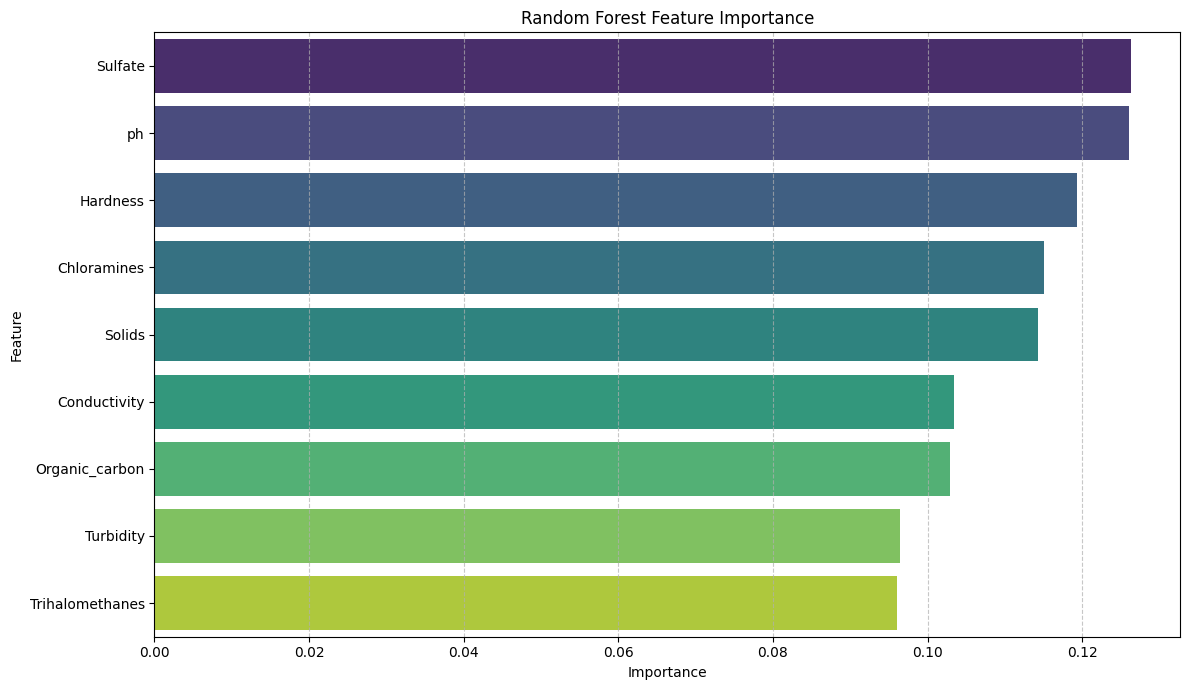

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 獲取特徵重要性
feature_importances = model.feature_importances_

# 獲取特徵名稱
feature_names = X.columns

# 創建 DataFrame 以便排序和繪圖
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 根據重要性降序排列
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 繪製特徵重要性長條圖
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 將本地 CSV 檔案上傳到 Google Colab 的方法

您可以使用以下幾種方法將本地的 CSV 檔案上傳到 Google Colab 環境中：

1.  **使用 `files.upload()` (程式碼)**：這是一種常見的方式，適合上傳較小的檔案，檔案會暫時存放在 Colab 執行環境中，在執行時間結束後會被清除。
2.  **掛載 Google Drive (程式碼)**：如果您想上傳較大的檔案，或希望檔案在不同的 Colab Session 中保持可存取，掛載 Google Drive 是更好的選擇。您可以將檔案儲存在您的 Google Drive 中，然後在 Colab 中直接存取。
3.  **使用 Colab 左側的檔案瀏覽器 (手動)**：這是最直接的方式，您可以直接將檔案拖曳到 Colab 左側的檔案面板中。檔案會暫時存放在 Colab 執行環境中。

#### 方法一：使用 `google.colab.files.upload()` 上傳檔案

In [ ]:
from google.colab import files
import pandas as pd

# 這會打開一個檔案選擇器，讓您從本地電腦選擇檔案
uploaded = files.upload()

for fn in uploaded.keys():
  print('使用者上傳了檔案 "{name}" 檔案大小為 {length} 位元組'.format(
      name=fn, length=len(uploaded[fn])))

  # 假設您上傳的是 'water_potability.csv'
  # 您現在可以使用 pd.read_csv 讀取這個檔案
  try:
      df = pd.read_csv(fn)
      print(f"\n成功讀取檔案 '{fn}' 的前5行：")
      print(df.head())
      break # 假設我們只處理第一個上傳的檔案
  except Exception as e:
      print(f"讀取檔案 '{fn}' 時發生錯誤: {e}")

Saving water_potability.csv to water_potability.csv
使用者上傳了檔案 "water_potability.csv" 檔案大小為 525187 位元組

成功讀取檔案 'water_potability.csv' 的前5行：
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


#### 方法二：掛載 Google Drive

#### 方法三：使用 Colab 左側的檔案瀏覽器 (拖曳上傳)

1.  點擊 Colab 介面左側的檔案圖示 (看起來像一個文件夾)。
2.  在彈出的檔案面板中，您可以直接將本地電腦的 `water_potability.csv` 檔案拖曳到 `files` 或 `/content` 資料夾中。
3.  上傳完成後，您就可以像這樣讀取它：

    ```python
    import pandas as pd
    df = pd.read_csv('water_potability.csv')
    print(df.head())
    ```

請選擇最適合您需求的方法來上傳您的 `water_potability.csv` 檔案。一旦檔案上傳成功，您的原始程式碼應該就能正常運作了。